## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




# AI Assignment 6: House Price Prediction Using California Housing Data


## Introduction

In this assignment, I will build a simple regression model to predict median house values using the California Housing Dataset from sklearn. The main goal is to follow the basic machine learning project cycle, including importing libraries, loading the dataset, exploring the data, training a regression model, evaluating the model, and making a prediction using new input data.

In [47]:
# --- Imports ---
# Import libraries for data handling, visualization, and model building

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Data Collection and Loading

In this section, the California Housing Dataset is loaded from sklearn and converted into a pandas DataFrame. The target variable (MedHouseVal) is added to the dataset for further analysis and model building.

In [48]:
# --- Data Collection and Loading ---
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `fetch_california_housing()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:

# Load California Housing dataset
housing = fetch_california_housing()

# Convert features to DataFrame
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target column
df["MedHouseVal"] = housing.target

## Quick Check of Data

The first few rows of the dataset are displayed to understand the structure of the data and verify that the dataset has been loaded correctly.

In [49]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Add your code here:

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Data Information and Statistics

The dataset structure, data types, and summary statistics are examined to better understand the features and target variable.

In [50]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Observations

The dataset contains 20,640 records and 9 columns. All features are numerical and continuous. The target variable (MedHouseVal) is also continuous because it represents median house values. No categorical features are present in this dataset.

## EDA and Data Preprocessing

In this section, the dataset is checked for missing values and visualized to explore relationships between the features and the target variable (MedHouseVal).

In [51]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


### Missing Values Check

The dataset does not contain any missing values. All features and the target variable have complete records, so no additional preprocessing was required.

### Scatter Plot: Median Income vs House Value

A scatter plot is created to examine the relationship between median income (MedInc) and median house value (MedHouseVal).

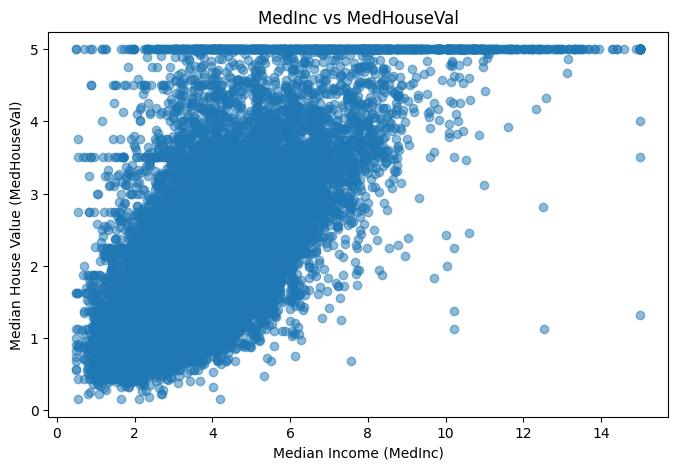

In [52]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.

# Add your code here:

plt.figure(figsize=(8,5))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.5
)

plt.xlabel("Median Income (MedInc)")
plt.ylabel("Median House Value (MedHouseVal)")
plt.title("MedInc vs MedHouseVal")

plt.show()

### Scatter Plot Function

To avoid repeating code, a function is created to automatically generate scatter plots for different features against the target variable (MedHouseVal).

In [53]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:

def scatter_plot(features, target):

    for feature in features:

        plt.figure(figsize=(8,5))

        plt.scatter(
            df[feature],
            df[target],
            alpha=0.5
        )

        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f"{feature} vs {target}")

        plt.show()

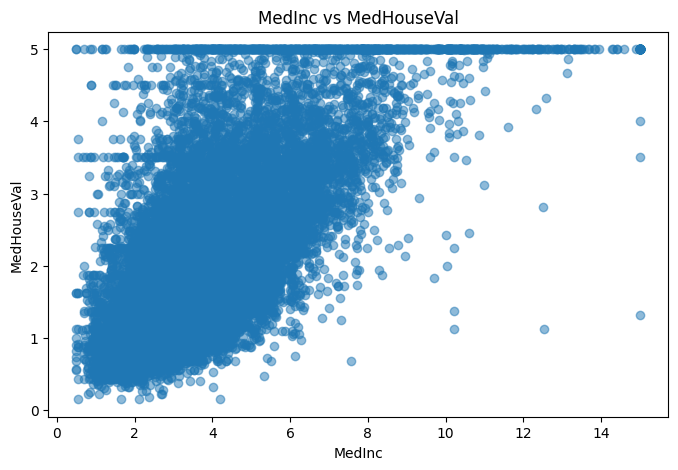

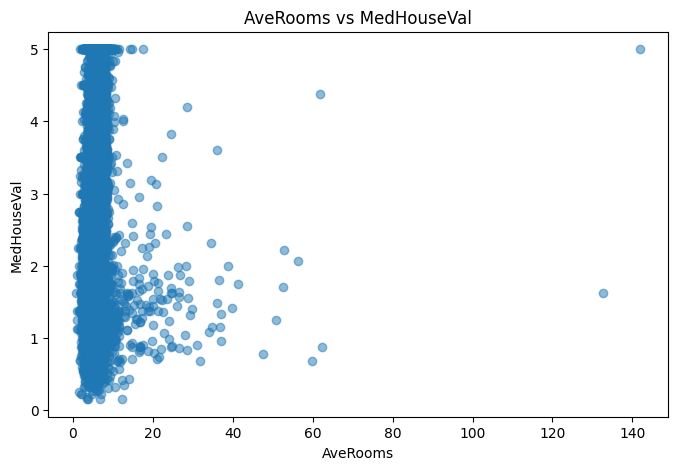

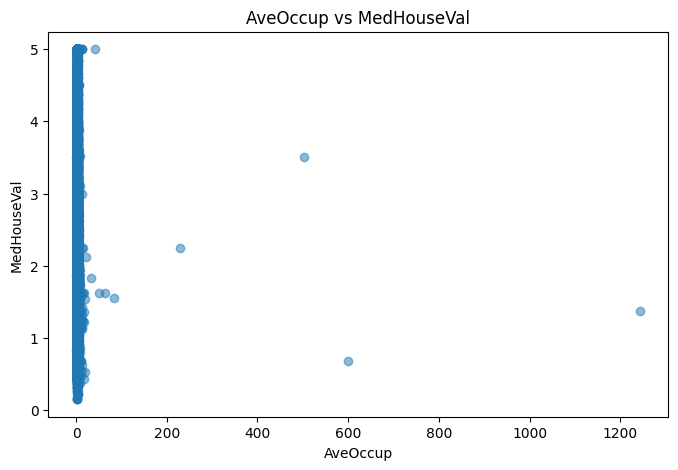

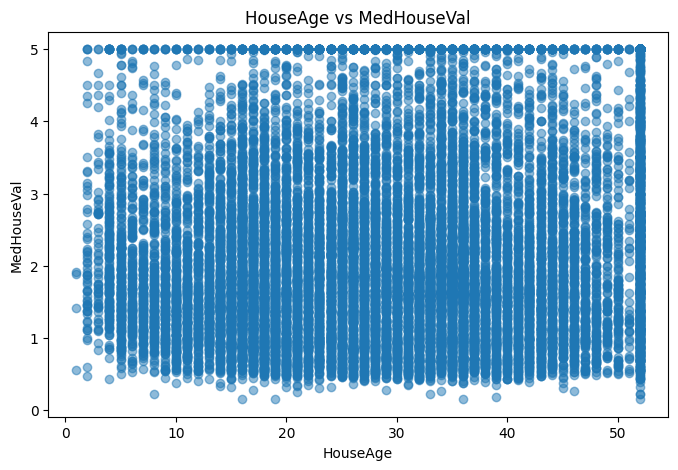

In [54]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
# Target: 'MedHouseVal'

# Add your code here:

features = [
    "MedInc",
    "AveRooms",
    "AveOccup",
    "HouseAge"
]

scatter_plot(features, "MedHouseVal")

### Scatter Plot Observations

The scatter plots show that **MedInc** has the strongest positive relationship with the target variable (MedHouseVal). The other features, such as **AveRooms**, **AveOccup**, and **HouseAge**, show weaker or less clear relationships with house values.

## ML Model Training

In this section, the dataset is divided into training and testing sets. A Linear Regression model is then trained using the training data to predict median house values.

In [55]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:

# Define features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Linear Regression Model

A Linear Regression model is selected because the target variable (MedHouseVal) is continuous. The model is trained using the training dataset.

In [56]:
# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.

# Define your regression model here:

# Define the regression model
model = LinearRegression()

In [57]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# Add your code here:

# Train the model
model.fit(X_train, y_train)

LinearRegression()

## Model Evaluation

The trained model is evaluated using the test dataset. Two evaluation metrics are used: Root Mean Squared Error (RMSE) and R-squared (R²), which measure the prediction error and the overall performance of the regression model.

In [58]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Predict on the test set and calculate the evaluation metrics:

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R-squared:", r2)

RMSE: 0.7455813830127764
R-squared: 0.5757877060324508


### Model Evaluation Results

The model achieved an RMSE of approximately **0.75**, indicating that the prediction error is relatively low. The R² score is approximately **0.58**, meaning that the model explains about **58%** of the variation in median house values. Overall, the Linear Regression model provides a reasonable baseline for predicting house prices.

## Model Prediction

The trained model is used to predict the median house value for a new house based on a new set of feature values.

In [59]:
# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Example new data: 'MedInc' = 3, 'HouseAge' = 30, 'AveRooms' = 6, 'AveOccup' = 3, 'Latitude' = 34, 'Longitude' = -118, 'AveBedrms' = 1, 'Population' = 1500
# Hint: Use `.predict()` on a new data array.

# Add your prediction code here:

# New house data
new_house = pd.DataFrame([{
    "MedInc": 3,
    "HouseAge": 30,
    "AveRooms": 6,
    "AveBedrms": 1,
    "Population": 1500,
    "AveOccup": 3,
    "Latitude": 34,
    "Longitude": -118
}])

prediction = model.predict(new_house)

print("Predicted Median House Value:", prediction[0])

Predicted Median House Value: 1.5486633337100812


In [60]:
# Conclusion
print("""
Conclusion

In this assignment, a Linear Regression model was developed to predict median house values using the California Housing Dataset.
The dataset was explored, checked for missing values, and visualized using scatter plots.
The model was trained and evaluated using RMSE and R² metrics.
Finally, the trained model was used to predict house values using new input data.
""")


Conclusion

In this assignment, a Linear Regression model was developed to predict median house values using the California Housing Dataset.
The dataset was explored, checked for missing values, and visualized using scatter plots.
The model was trained and evaluated using RMSE and R² metrics.
Finally, the trained model was used to predict house values using new input data.

